In [2]:
from utils import *

In [3]:
def random_reverse_edge(edges):
    """
    Returns:
        reversed_edges: edge list with one randomly chosen edge reversed.
        removed_edges: edge list with that same edge removed.
    Raises:
        ValueError if no edge can be reversed without creating a cycle.
    """
    edges = list(edges)
    candidates = edges[:]
    random.shuffle(candidates)

    for u, v in candidates:
        removed_edges = [e for e in edges if e != (u, v)]
        reversed_edges = removed_edges + [(v, u)]

        G = nx.DiGraph(reversed_edges)
        if nx.is_directed_acyclic_graph(G):
            return reversed_edges, removed_edges

In [4]:
from collections import deque

def canonical(edges):
    """Convert edge list to hashable representation."""
    return tuple(sorted(edges))


def is_acyclic(edges):
    """Check whether directed edge set is a DAG."""
    G = nx.DiGraph()
    G.add_edges_from(edges)
    return nx.is_directed_acyclic_graph(G)


def generate_neighbors(edges, n):
    """
    Generate all DAGs differing by one edge addition or removal.
    """
    edges = set(edges)
    neighbors = []

    # ---------
    # Remove one edge
    # ---------
    for e in edges:
        new_edges = edges.copy()
        new_edges.remove(e)

        neighbors.append(new_edges)


    # ---------
    # Add one edge
    # ---------
    for u in range(1, n + 1):
        for v in range(1, n + 1):

            if u == v:
                continue

            if (u, v) in edges:
                continue

            new_edges = edges.copy()
            new_edges.add((u, v))

            if is_acyclic(new_edges):
                neighbors.append(new_edges)

    return neighbors


def find_equivalence_class(edges, confounding, n):
    start = set(edges)
    visited = {canonical(start)}
    result = [start]
    queue = deque([start])
    while queue:
        current = queue.popleft()
        for neighbor in generate_neighbors(current, n):
            key = canonical(neighbor)
            if key in visited:
                continue
            if get_solver(start, neighbor, confounding, confounding, n) and get_solver(neighbor, start, confounding, confounding, n):
                visited.add(key)
                result.append(neighbor)
                queue.append(neighbor)
    return result

In [ ]:
# Test if an edge can be reserved implies that this edge can be removed

n = 5
count = 0
while count < 2000:
    num_confounding = random.randint(1, n * (n - 1) // 2)
    G1 = random_dag(n,random.uniform(0.1,0.9))
    B = random_confounding(n,num_confounding)
    E1 = G1.edges()
    try:
        E2, E_reduced = random_reverse_edge(E1)
        G2 = nx.DiGraph()
        G_r = nx.DiGraph()
        V = range(1,n+1)
        G2.add_nodes_from(V)
        G_r.add_nodes_from(V)
        G2.add_edges_from(E2)
        G_r.add_edges_from(E_reduced)
        if check_inclusion_full(G1,G2,B,B):
            count = count + 1
            print(f"Count: {count}")
            if check_inclusion_full(G1,G_r,B,B) == False:
                print ("Stop")
                print (E1,E2,B)
                break
    except Exception:
        continue


In [ ]:
# Test if an edge can be reversed implies that there is a bidirected edge connecting the endpoints of this edge

n = 5
count = 0
while count < 2000:
    num_confounding = random.randint(1, n * (n - 1) // 2)
    G1 = random_dag(n,random.uniform(0.1,0.9))
    B = random_confounding(n,num_confounding)
    E1 = G1.edges()
    try:
        E2, E_reduced = random_reverse_edge(E1)
        G2 = nx.DiGraph()
        V = range(1,n+1)
        G2.add_nodes_from(V)
        G2.add_edges_from(E2)
        if check_inclusion_full(G1,G2,B,B):
            e = next(x for x in E1 if x not in E_reduced)
            e2 = (e[1], e[0])
            if e in B or e2 in B:
                count = count + 1
                print(f"Count: {count}")
            else:
                print ("Stop")
                print (E1,E_reduced,B)
                break
    except Exception:
        continue


Below is study on the structure of the induced graph, we first sample a case that a directed edge can be reversed.

In [ ]:
n = 4
for i in range(1000):
    num_confounding = random.randint(1, 5)
    G1 = random_dag(n,0.3)
    B = random_confounding(n,num_confounding)
    E1 = G1.edges()
    try:
        E2, E_reduced = random_reverse_edge(E1)
        G2 = nx.DiGraph()
        V = range(1,n+1)
        G2.add_nodes_from(V)
        G2.add_edges_from(E2)
        if check_inclusion_full(G1,G2,B,B):
            print (B)
            print (next(x for x in E1 if x not in E_reduced))
            plot_auxiliary(G1,G2,B,B)
            break
    except Exception:
        continue

We then analyze how the induced graph looks like and how the vertex cover could be selected.


The first graph, second graph and third graph correspond to $G_{\mathcal{I}}(G_1,G_2)$, $G_{\mathcal{I}}(G_1,G^e)$ and $G_{\mathcal{I}}(G_2,G_1)$, respectively.

We see that, in the first graph, the vertex $(u,u)$ is never required.

True
[(1, 3)]
(1, 3)


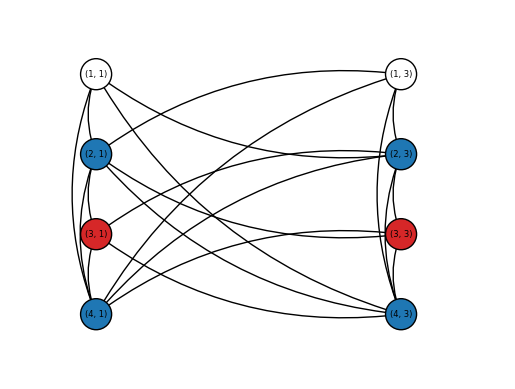

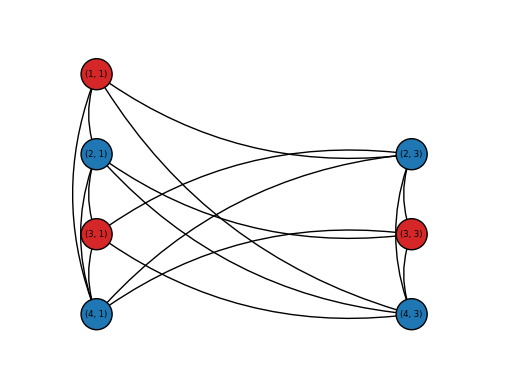

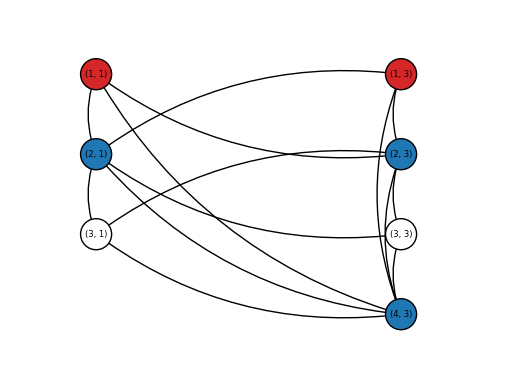

In [ ]:
n = 4
for i in range(1000):
    num_confounding = random.randint(1, 5)

    G1 = random_dag(n,0.3)
    B = random_confounding(n,num_confounding)
    E1 = G1.edges()
    try:
        E2, E_reduced = random_reverse_edge(E1)
        G2 = nx.DiGraph()
        G_r = nx.DiGraph()
        V = range(1,n+1)
        G2.add_nodes_from(V)
        G_r.add_nodes_from(V)
        G2.add_edges_from(E2)
        G_r.add_edges_from(E_reduced)
        if check_inclusion_full(G1,G2,B,B) and check_inclusion_full(G2,G1,B,B):
            print (check_inclusion_full(G1,G_r,B,B))
            print (B)
            print (next(x for x in E1 if x not in E_reduced)) # print the reversed edge u -> v
            plot_auxiliary(G1,G2,B,B)
            plot_auxiliary(G1,G_r,B,B)
            plot_auxiliary(G2,G1,B,B)
            break
    except Exception:
        continue